In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('e commerce dataset (1).csv', encoding='latin1')

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
print("\nMissing values:")
print(df.isnull().sum())




Missing values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [6]:
print("\nStatistics:")
print(df.describe())


Statistics:
            Row ID   Postal Code         Sales     Quantity     Discount  \
count  9994.000000   9994.000000   9994.000000  9994.000000  9994.000000   
mean   4997.500000  55190.379428    229.858001     3.789574     0.156203   
std    2885.163629  32063.693350    623.245101     2.225110     0.206452   
min       1.000000   1040.000000      0.444000     1.000000     0.000000   
25%    2499.250000  23223.000000     17.280000     2.000000     0.000000   
50%    4997.500000  56430.500000     54.490000     3.000000     0.200000   
75%    7495.750000  90008.000000    209.940000     5.000000     0.200000   
max    9994.000000  99301.000000  22638.480000    14.000000     0.800000   

            Profit  
count  9994.000000  
mean     28.656896  
std     234.260108  
min   -6599.978000  
25%       1.728750  
50%       8.666500  
75%      29.364000  
max    8399.976000  


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

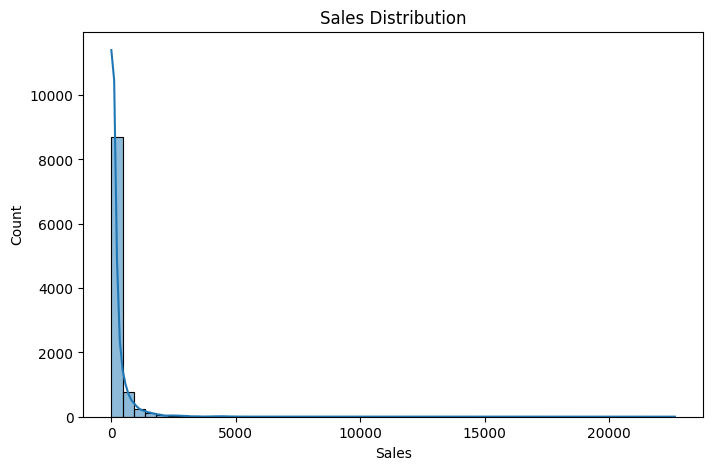

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['Sales'], bins=50, kde=True)
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.show()

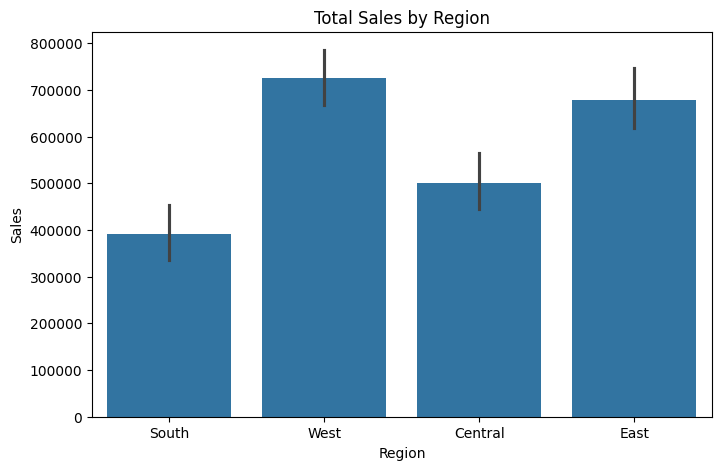

In [9]:
plt.figure(figsize=(8,5))
sns.barplot(x='Region', y='Sales', data=df, estimator=sum)
plt.title('Total Sales by Region')
plt.show()

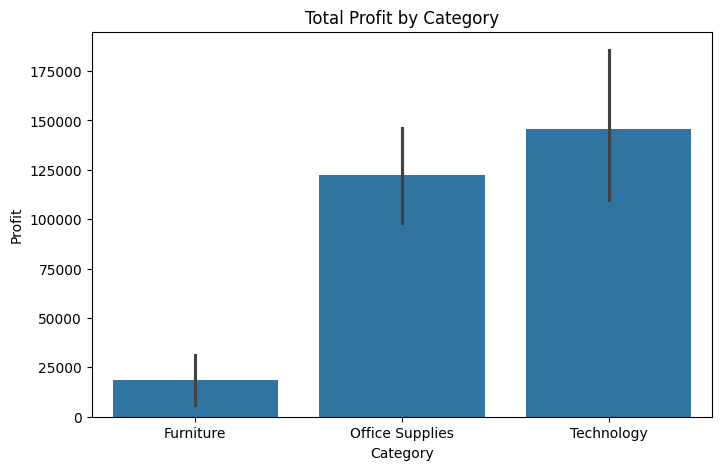

In [10]:
plt.figure(figsize=(8,5))
sns.barplot(x='Category', y='Profit', data=df, estimator=sum)
plt.title('Total Profit by Category')
plt.show()


In [11]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [27]:
customer_data = df.groupby("Customer Name").agg({
    "Sales": "sum",
    "Profit": "sum"
}).reset_index()

In [28]:
X = customer_data[["Sales", "Profit"]]

In [29]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [30]:
model = KMeans(n_clusters=3, random_state=42)
model.fit(X_scaled)

KMeans(n_clusters=3, random_state=42)

In [32]:
customer_data["Segment"] = model.labels_

In [33]:
customer = pd.DataFrame([[5000, 800]], columns=["Sales", "Profit"])
customer_scaled = scaler.transform(customer)
prediction = model.predict(customer_scaled)

In [38]:
print(customer_data.head(10))
print("Predicted Segment:", prediction[0])

        Customer Name      Sales     Profit  Segment
0       Aaron Bergman    886.156   129.3465        0
1       Aaron Hawkins   1744.700   365.2152        0
2      Aaron Smayling   3050.692  -253.5746        0
3     Adam Bellavance   7755.620  2054.5885        1
4           Adam Hart   3250.337   281.1890        0
5  Adam Shillingsburg   3255.310    64.5374        0
6       Adrian Barton  14473.571  5444.8055        1
7         Adrian Hane   1735.514    -2.3146        0
8        Adrian Shami     58.820    21.8496        0
9         Aimee Bixby    966.710   313.6597        0
Predicted Segment: 2
